## Postprocessing for Analytic Release Model & Comparison with Numeric Model ##

Import analytic model results

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

# --- 1. LOAD DATA FROM JSON FILE ---
# Define Results folder path
results_folder = "./results"
results_file = os.path.join(results_folder, "LiOx_analytic_results.json")

print(f"--- Loading data from {results_file} ---")

# Open and load the JSON file
try:
    with open(results_file, 'r') as f:
        results_data = json.load(f)
    print(f"Successfully loaded results from {results_file}")

    results_analytic = results_data["simulation_results"]
    params_analytic = results_data["simulation_parameters"]

    # --- CONVERT DATA BACK TO NUMPY ARRAYS FOR ANALYSIS ---
    # The data is loaded as lists of lists, so we convert them back to NumPy arrays
    time_hours = np.array(results_analytic["time_hours"])
    release_rate = np.array(results_analytic["release_rate_atoms_per_s"])
    cumulative_release = np.array(results_analytic["cumulative_release_atoms"])
    inventory = np.array(results_analytic["inventory_atoms"])
    radial_positions = np.array(results_analytic["radial_positions_m"])
    concentration_profiles = np.array(results_analytic["concentration_profiles_atoms_per_m3"])
    time_array = np.array(results_analytic["time_s"])
    radial_pos = np.array(results_analytic["radial_positions_m"])

    t_change = params_analytic["t_change_s"]
    t_end = params_analytic["t_end_s"]

    G1 = params_analytic["initial_generation_rate_atoms_per_m3_s"]
    a = params_analytic["grain_radius_m"]

except FileNotFoundError:
    print(f"Error: The file {results_file} was not found.")
except json.JSONDecodeError:
    print(f"Error: Could not decode the JSON data from {results_file}.")


print("--- Data loaded and variables reconstructed successfully ---\n")


--- Loading data from ./results/LiOx_analytic_results.json ---
Successfully loaded results from ./results/LiOx_analytic_results.json
--- Data loaded and variables reconstructed successfully ---



Grain Concentration Profiles vs Time

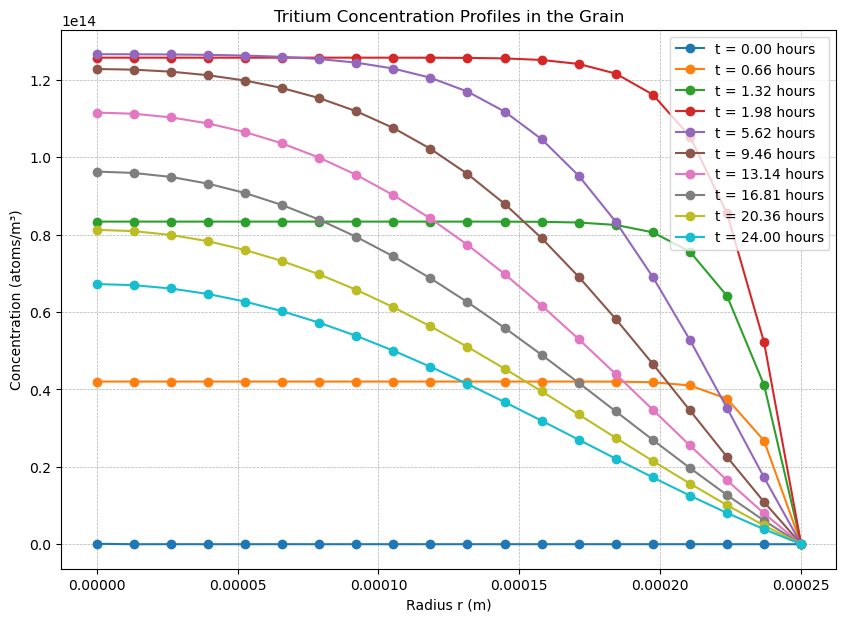

In [43]:
## Plot 1: Concentration Profiles at Different Times
fig1, ax1 = plt.subplots(figsize=(10, 7))
        
# Select a few time points to plot for clarity
num_profiles_to_plot = 10
n_irr = num_profiles_to_plot // 3
n_post = num_profiles_to_plot - n_irr

# Generate equally spaced times in each region
irr_times = np.linspace(0, t_change, n_irr, endpoint=False)
post_times = np.linspace(t_change, t_end, n_post)

# Find closest indices in time_array for each time
irr_indices = [np.abs(time_array - t).argmin() for t in irr_times]
post_indices = [np.abs(time_array - t).argmin() for t in post_times]

# Combine and ensure unique and sorted, always include t=0 and t_end
plot_indices = np.unique(np.concatenate(([0], irr_indices, post_indices, [len(time_array) - 1])))

for i in plot_indices:
    time_val_hours = time_array[i] / 3600
    # Plot concentration vs. radius
    ax1.plot(radial_pos, concentration_profiles[i], marker='o', linestyle='-', label=f't = {time_val_hours:.2f} hours')

    ax1.set_title('Tritium Concentration Profiles in the Grain')
    ax1.set_xlabel('Radius r (m)')
    ax1.set_ylabel('Concentration (atoms/m³)')
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.legend(loc = 'best')

Grain Release Rate & Cumulative Release vs Time

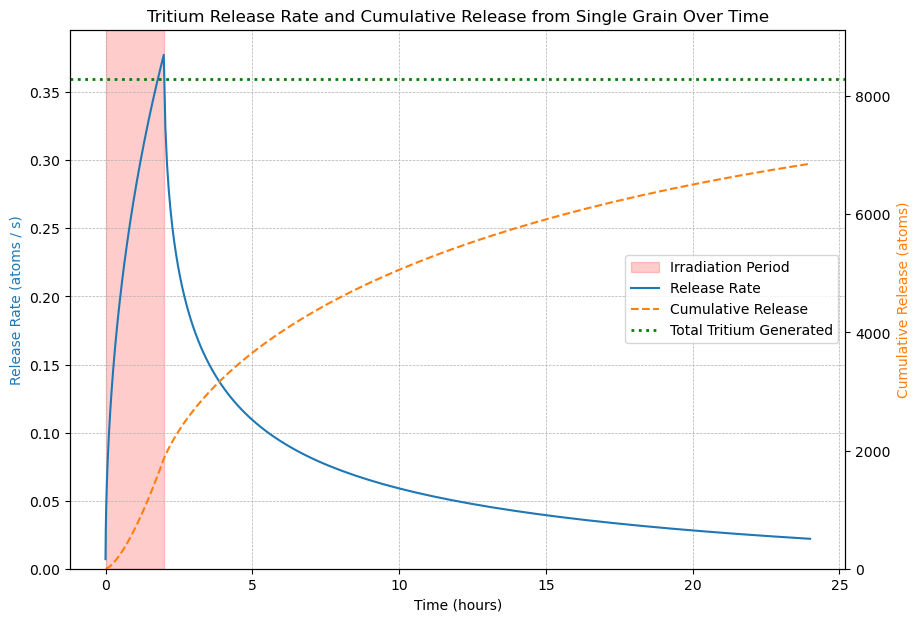

In [44]:
## Plot 2: Release Rate vs. Time
fig2, ax2 = plt.subplots(figsize=(10, 7))
    
# Highlight irradiation period
ax2.axvspan(0, t_change / 3600, color='red', alpha=0.2, label='Irradiation Period')

# Plot release rate vs time
ax2.plot(time_array / 3600, release_rate, linestyle='-', color='tab:blue', label='Release Rate')

ax2.set_title('Tritium Release Rate and Cumulative Release from Single Grain Over Time')
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Release Rate (atoms / s)', color='tab:blue')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.set_ylim(bottom=0)

# Secondary y-axis for cumulative release
ax2b = ax2.twinx()
ax2b.plot(time_array / 3600, cumulative_release, color='tab:orange', linestyle='--', label='Cumulative Release')
ax2b.set_ylabel('Cumulative Release (atoms)', color='tab:orange')
ax2b.set_ylim(bottom=0)

# Add horizontal line for total tritium generated during irradiation
grain_volume = (4/3) * np.pi * a**3
total_generated = G1 * t_change * grain_volume
ax2b.axhline(total_generated, color='green', linestyle=':', linewidth=2, label='Total Tritium Generated')
ax2b.set_ylim(top=1.1 * total_generated)  # Set upper limit to 110% of total generated for better visibility

# Legends for both axes
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center right')

Tritium Inventory in Grain vs Time

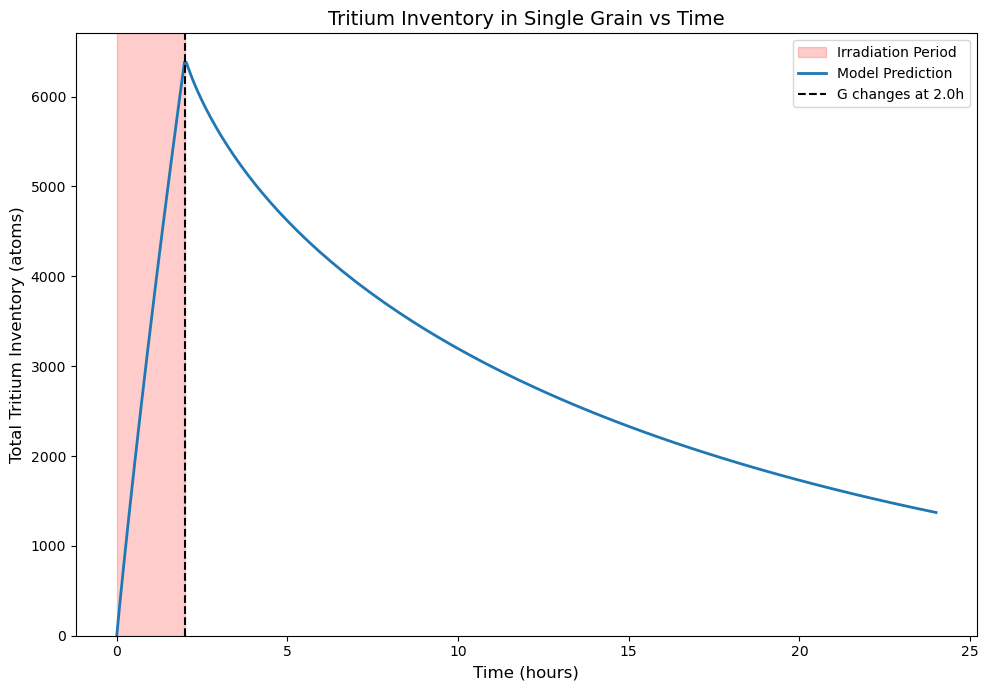

In [45]:

## Plot 3: Tritium Inventory vs. Time
fig3, ax3 = plt.subplots(figsize=(10, 7))

# Highlight irradiation period
ax3.axvspan(0, t_change / 3600, color='red', alpha=0.2, label='Irradiation Period')

ax3.plot(time_array / 3600, inventory, lw=2, label='Model Prediction')
ax3.axvline(x=t_change / 3600, color='k', linestyle='--', label=f'G changes at {t_change / 3600:.1f}h')
ax3.set_xlabel('Time (hours)', fontsize=12)
ax3.set_ylabel('Total Tritium Inventory (atoms)', fontsize=12)
ax3.set_title(f'Tritium Inventory in Single Grain vs Time', fontsize=14)
ax3.legend()
ax3.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Numeric vs Analytic Results Comparison

--- Loading data from ./results/LiOx_powder_results.json ---


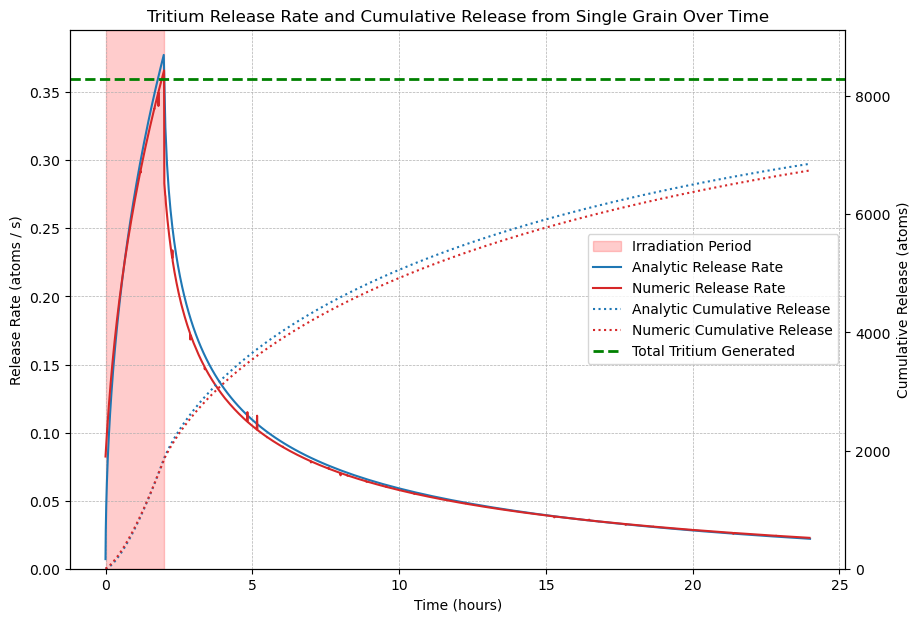

In [46]:
# Load numeric results for comparison
numeric_results_file = os.path.join(results_folder, "LiOx_powder_results.json")

print(f"--- Loading data from {numeric_results_file} ---")

with open(numeric_results_file, 'r') as f:
    data = json.load(f)

# Extract parameters and results from the loaded numeric results data
params_numeric = data['simulation_parameters']
results_numeric = data['simulation_results']

time_numeric = np.array(results_numeric['time_s'])
data_intervals = np.diff(time_numeric, prepend=0)

grain_release_rate_numeric = np.array(results_numeric['grain_release_rate'])
grain_cumulative_release = np.cumsum(grain_release_rate_numeric * data_intervals)  # Cumulative release from a single grain



## Plot: Release Rate vs. Time
fig4, ax4 = plt.subplots(figsize=(10, 7))
    
# Highlight irradiation period
ax4.axvspan(0, t_change / 3600, color='red', alpha=0.2, label='Irradiation Period')

# Plot release rate vs time
ax4.plot(time_array / 3600, release_rate, linestyle='-', color='tab:blue', label='Analytic Release Rate')
ax4.plot(time_numeric / 3600, grain_release_rate_numeric, linestyle='-', color='tab:red', label='Numeric Release Rate')

ax4.set_title('Tritium Release Rate and Cumulative Release from Single Grain Over Time')
ax4.set_xlabel('Time (hours)')
ax4.set_ylabel('Release Rate (atoms / s)')
ax4.grid(True, which='both', linestyle='--', linewidth=0.5)
ax4.set_ylim(bottom=0)

# Secondary y-axis for cumulative release
ax4b = ax4.twinx()
ax4b.plot(time_array / 3600, cumulative_release, color='tab:blue', linestyle=':', label='Analytic Cumulative Release')
ax4b.plot(time_numeric / 3600, grain_cumulative_release, color='tab:red', linestyle=':', label='Numeric Cumulative Release')
ax4b.set_ylabel('Cumulative Release (atoms)')
ax4b.set_ylim(bottom=0)

# Add horizontal line for total tritium generated during irradiation
grain_volume = (4/3) * np.pi * a**3
total_generated = G1 * t_change * grain_volume
ax4b.axhline(total_generated, color='green', linestyle='--', linewidth=2, label='Total Tritium Generated')
ax4b.set_ylim(top=1.1 * total_generated)  # Set upper limit to 110% of total generated for better visibility

# Legends for both axes
lines, labels = ax4.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4.legend(lines + lines2, labels + labels2, loc='center right')
